In [1]:
# — — — — — — -Importing Packages — — — — — — — — — — — -
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore") 

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# model
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, ward
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import AffinityPropagation
from sklearn.cluster import MeanShift, estimate_bandwidth

# grid search
from sklearn.model_selection import GridSearchCV

# evaluation
from sklearn.metrics.cluster import silhouette_score
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import *

In [2]:
from sklearn_extra.cluster import KMedoids 
from sklearn.cluster import KMeans

In [3]:
# — — — — — — -Assigning Data: Dummy Data used in example above — — — — — — — — — — — — — — — — — — 
df = pd.read_csv('data/정제데이터/구별데이터_스케일링.csv', encoding='cp949')

# 환경불평등지수
- 기초수급자_인구밀도 + (1-인당녹지면적)

In [4]:
df['환경불평등지수'] = df.기초수급자_인구밀도 + (1- df.인당녹지면적)

In [5]:
df.head(3)

,시군구,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),도시재생사업수,환경불평등지수
0,강남구,0.258356,0.891770,1.000000,0.50,0.285714,0.827140,1.000000,0.606061,0.0,0.431216
1,강동구,0.518524,0.461778,0.601108,0.75,0.571429,0.715354,0.259889,0.525253,0.4,0.803171
2,강북구,1.000000,0.241271,0.141629,0.25,0.571429,0.501950,0.066923,0.565657,0.6,1.498050


In [6]:
data = df[['총공시지가평균','환경불평등지수']]

In [7]:
centers = [[4, 5], [9, 10]]

In [8]:
k=3
KMobj = KMedoids(n_clusters=k, random_state=200).fit(data)

# 클러스터링 결과 각 데이터가 몇 번째 그룹에 속하는지 저장
df['cluster'] = KMobj.fit_predict(data)

In [9]:
df.head(3)

,시군구,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),도시재생사업수,환경불평등지수,cluster
0,강남구,0.258356,0.891770,1.000000,0.50,0.285714,0.827140,1.000000,0.606061,0.0,0.431216,2
1,강동구,0.518524,0.461778,0.601108,0.75,0.571429,0.715354,0.259889,0.525253,0.4,0.803171,1
2,강북구,1.000000,0.241271,0.141629,0.25,0.571429,0.501950,0.066923,0.565657,0.6,1.498050,0


Gulim


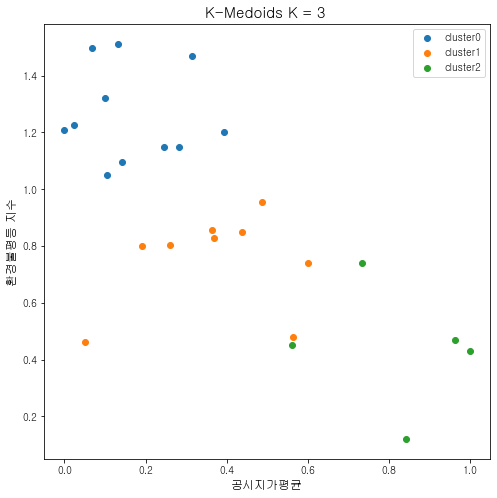

In [13]:
import matplotlib.pyplot as plt

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

plt.figure(figsize = (8, 8))

for i in range(k):
    plt.scatter(df.loc[df['cluster'] == i, '총공시지가평균'], df.loc[df['cluster'] == i, '환경불평등지수'], label = 'cluster' + str(i))

plt.legend()
plt.title('K-Medoids K = %d '%k , size = 15)
plt.xlabel('공시지가평균', size = 12)
plt.ylabel('환경불평등 지수', size = 12)
plt.show()

In [11]:
cluster_cnt = df.groupby('cluster').agg({'시군구':'count'}).reset_index()
cluster_des = df.groupby('cluster').mean().reset_index()

In [14]:
a = pd.merge(cluster_cnt,cluster_des)

In [15]:
import dataframe_image as dfi

dfi.export(a, './image/10-2구별_K-Medoids_describe.png', max_cols = -1, max_rows = -1)

In [16]:
df[df.cluster==0].시군구.unique()

array(['강북구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구', '동대문구', '양천구',
       '은평구', '중랑구'], dtype=object)

# 실루엣 계수

In [ ]:
from sklearn.metrics import silhouette_score
 
silhouette_score(df, df['cluster'], metric='euclidean')

In [ ]:
from sklearn.metrics import silhouette_samples

# 모든 개별 데이터에 실루엣 계수값을 구함. 
score_samples = silhouette_samples(df, df['cluster'])
print('silhouette_samples( ) return 값의 shape' , score_samples.shape)

# 실루엣 계수 컬럼 추가
df['silhouette_coeff'] = score_samples

# 모든 데이터의 평균 실루엣 계수값을 구함. 
average_score = silhouette_score(df, df['cluster'])
print(' Silhouette Analysis Score:'.format(average_score))

In [ ]:
df.groupby('cluster')['silhouette_coeff'].mean()

## 데이터 병합(시군구)

In [ ]:
df

In [ ]:
df2 = pd.read_csv('2차군집화_스케일링_구.csv', encoding='cp949')
df2

In [ ]:
그리드행정동 = df2[['행정동']]
그리드행정동

In [ ]:
df3 = pd.concat([df,그리드행정동], axis=1)
df3

In [ ]:
df3 = df3[df3.cluster==0]
df3

In [ ]:
list(np.array(df3['행정동'].tolist()))

# K-means Elbow curve

In [ ]:
distortions = []
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df)
    distortions.append(kmeans.inertia_)

fig = plt.figure(figsize=(10, 5))
plt.plot(range(2, 20), distortions)
plt.grid(True)
plt.title('Elbow curve')
plt.show()

K-Means의 k를 설정하기 위해 Elbow curve를 그림

k=4 일때 급격한 변화가 일어난 것으로 보아 cluster 수를 4로 설정하기로 하였다(가설)